# Plotting Exposure Times

Plot exposure times.

Author: Qiushi Chris Tian

From: interactive_plotting.ipynb

Created: 2026-10-01

Updated: 

## Interactive Setting

Requires `ipyml`. Enable with either `%matplotlib ipympl` or `%matplotlib widget`.

In [1]:
%matplotlib inline

In [2]:
%matplotlib ipympl

## Imports and Style

In [3]:
from pathlib import Path
from astropy.table import Table
from astropy.time import Time
import numpy as np
import json
from datetime import datetime

from dep import mpl, plt, va
mdates = mpl.dates

import newport

In [4]:
from target_phot import TARGET, TMIN, TMAX

In [5]:
# plt.rcParams["font.family"] = "serif"
# # plt.rcParams["font.serif"] = ["serif"]

In [6]:
# plt.rcParams["font.sans-serif"]

## Constants/Preamble

In [7]:
SAVE_PATH = 'data/tables/opt_comp_stars/TOI-1410/exptime.pdf'

X_TITLE = 0.18
Y_TITLE = 0.92
SHAREY = False
FONTSIZE = 11
FIG_WIDTH = 8
FIG_HEIGHT_PER_PANEL = 1.7
SP_ADJ_TOP = 0.94
USE_PANEL_TITLES = True  # Toggle between panel titles and per-band legends

## Main

Target plot saved to data/tables/opt_comp_stars/TOI-1410/exptime.pdf


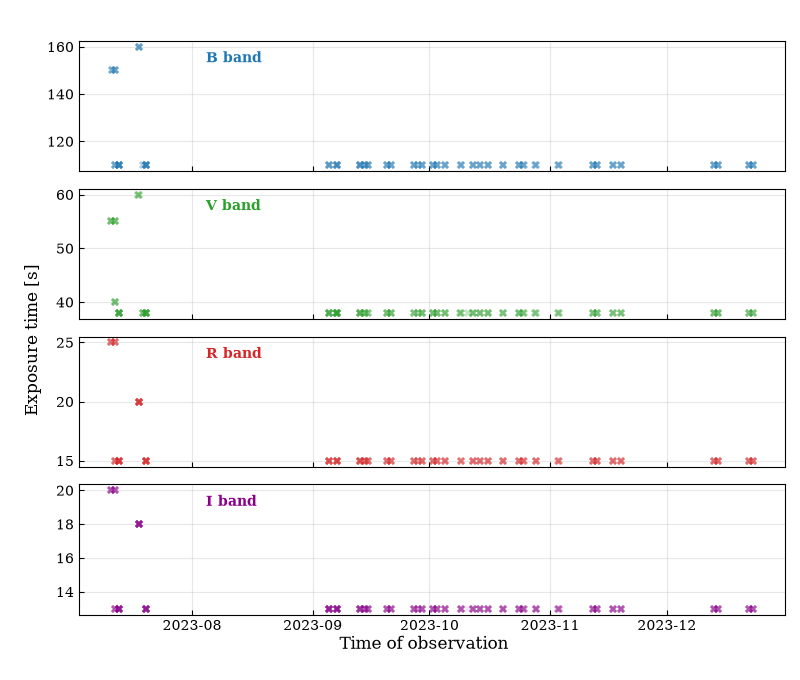

In [11]:
t = Table.read(newport.get_input_path(TARGET))
bands = sorted(np.unique(list(t['band'])), key=newport.BAND_ORDER_INDEX)

fig, axs = plt.subplots(
    nrows=len(bands),
    figsize=(FIG_WIDTH, FIG_HEIGHT_PER_PANEL * len(bands)),
    sharex=True,
    sharey=SHAREY,
)
if len(bands) == 1: axs = [axs]

for i, band in enumerate(bands):
    ax = axs[i]

    bt = t[t['band'] == band]

    if TMIN:
        TMIN_jd = Time(TMIN).jd
        bt = bt[bt['jd'] >= TMIN_jd]
    if TMAX:
        TMAX_jd = Time(TMAX).jd
        bt = bt[bt['jd'] <= TMAX_jd]
        
    # Time conversion
    dts = Time(bt['jd'], format='jd').to_datetime()
    
    # Unbinned points in background
    unbin_artist = ax.plot(
        dts, bt['exptime'], 'X', color=newport.COLORS[band],
        mew=0, alpha=0.1
    )
    
    # Panel Title (Color matched)
    if USE_PANEL_TITLES:
        ax.text(
            X_TITLE, Y_TITLE, f"{band} band", transform=ax.transAxes, 
            fontweight='bold', va='top', color=newport.COLORS[band],
            # FONTSIZE=11
        )
        # ax.legend(
        #     handles=[binned_artist, unbin_artist],
        #     labels=[binned_artist.get_label(), unbin_artist.get_label()],
        #     loc='upper left', bbox_to_anchor=(0.18, 0.95), ncol=1
        # )

    ax.grid(True, 'major', alpha=0.3)
    ax.grid(True, 'minor', alpha=0.1)
    ax.tick_params(axis='x', direction='in', which='both', labelsize=10)  # Ticks inside
    ax.tick_params(axis='y', direction='in')

    # Limit x-axis tick density and snap to months
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=8))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

fig.supxlabel("Time of observation", x=0.53, y=0.04)
fig.supylabel("Exposure time [s]", x=0.03, y=0.5)

plt.tight_layout()
fig.subplots_adjust(top=SP_ADJ_TOP)  # Make room for dual legends

if SAVE_PATH:
    plt.savefig(SAVE_PATH, bbox_inches='tight') # TODO verify if bbox tight is needed
    print(f"Target plot saved to {SAVE_PATH}")

plt.show()
# plt.close()

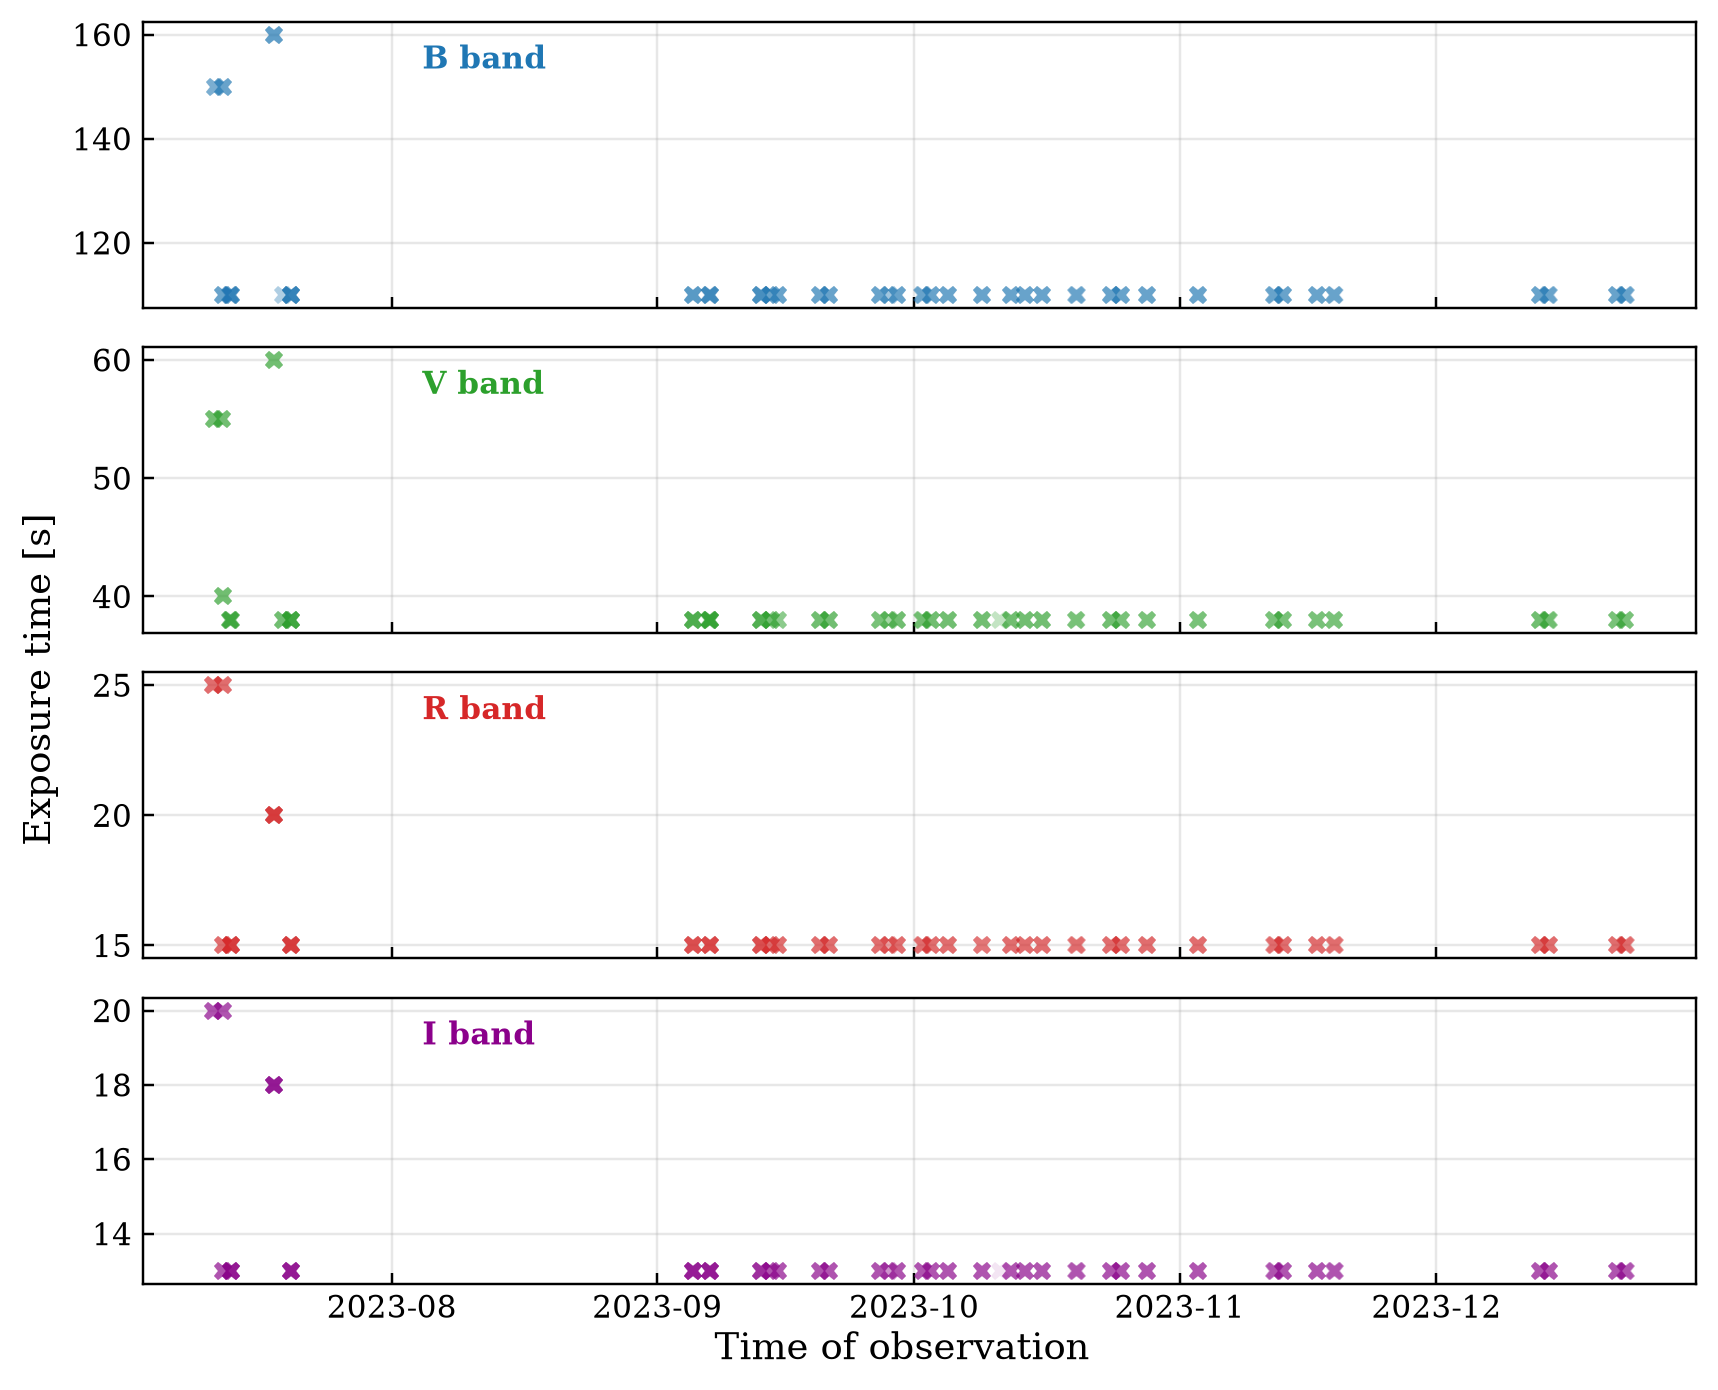

In [12]:
plt.gcf()

In [23]:
import statistics

In [27]:
statistics.mode(t['exptime'][:2])

np.float32(20.0)

In [26]:
t['exptime'][:2]

20.0
55.0
